### Exploratory Data Analysis

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# load the dataframe
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Summary Statistics

In [37]:
#Generate the summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
print("Median Values")
print(df.median(numeric_only=True))

Median Values
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64


In [39]:
# missing values for each attribute
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## BoxPlots and Histograms

In [40]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

### Histogram

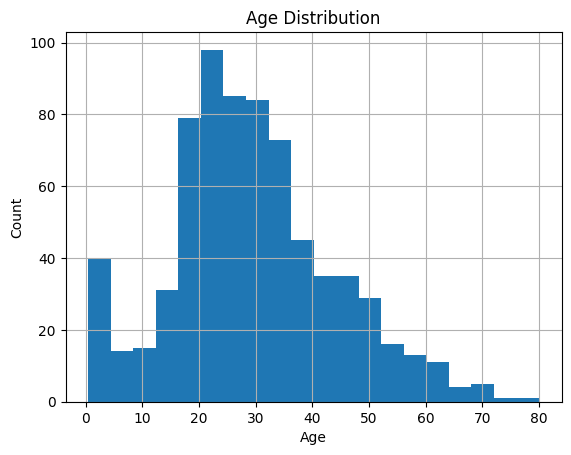

In [41]:
df['Age'].hist(bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

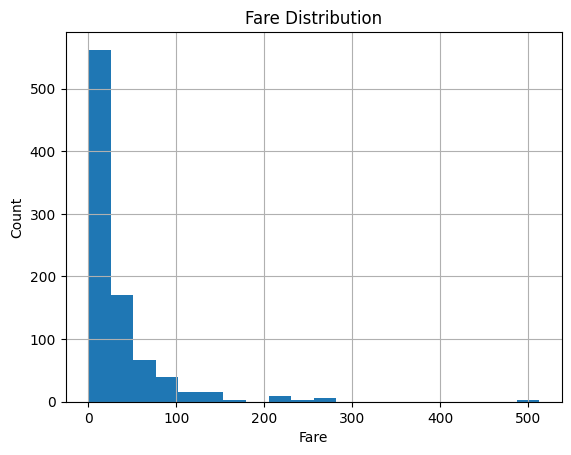

In [42]:
df['Fare'].hist(bins=20)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

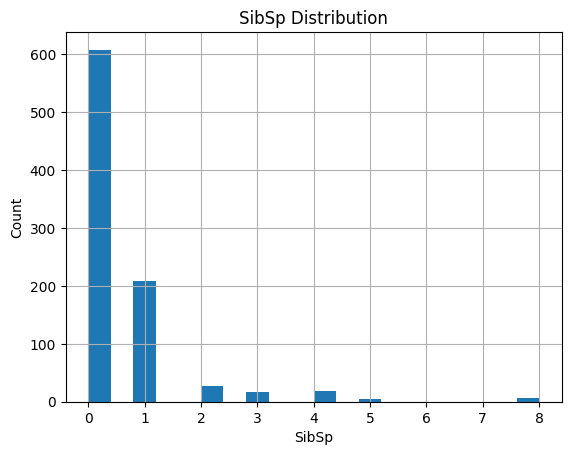

In [43]:
df['SibSp'].hist(bins=20)

plt.title('SibSp Distribution')
plt.xlabel('SibSp')
plt.ylabel('Count')
plt.show()

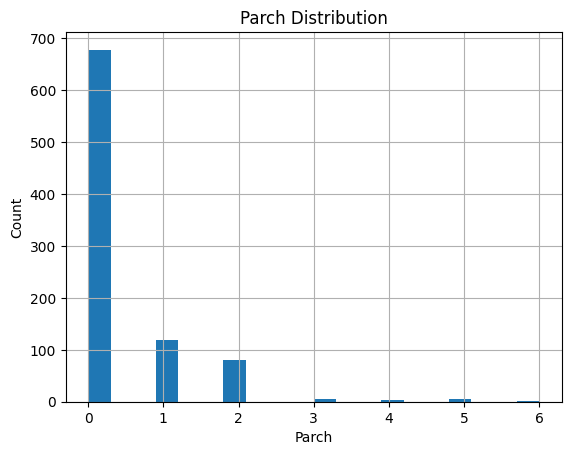

In [44]:
df['Parch'].hist(bins=20)

plt.title('Parch Distribution')
plt.xlabel('Parch')
plt.ylabel('Count')
plt.show()

### Boxplots

C:\Users\Samuel Oommen\AppData\Local\Temp\ipykernel_3476\1544614871.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


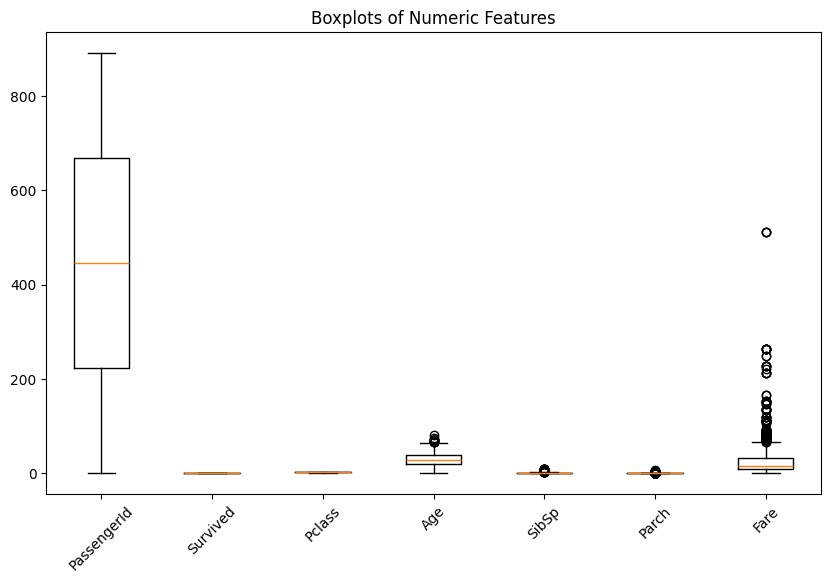

In [45]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
plt.boxplot(
    [numeric_df[col].dropna() for col in numeric_df.columns],
    labels=numeric_df.columns
)

plt.xticks(rotation=45)
plt.title('Boxplots of Numeric Features')
plt.show()

## Correlation/Pairplot

In [46]:
#create correlation matrix
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


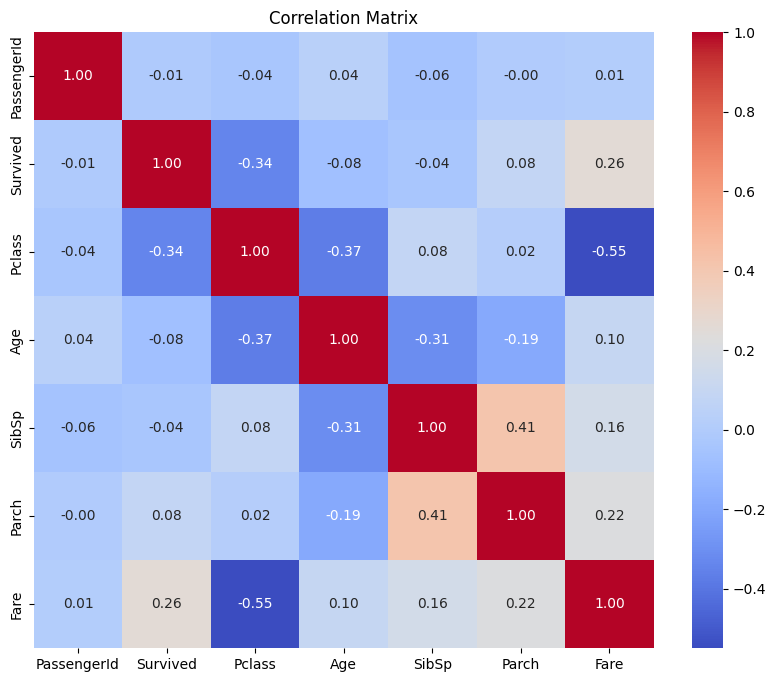

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

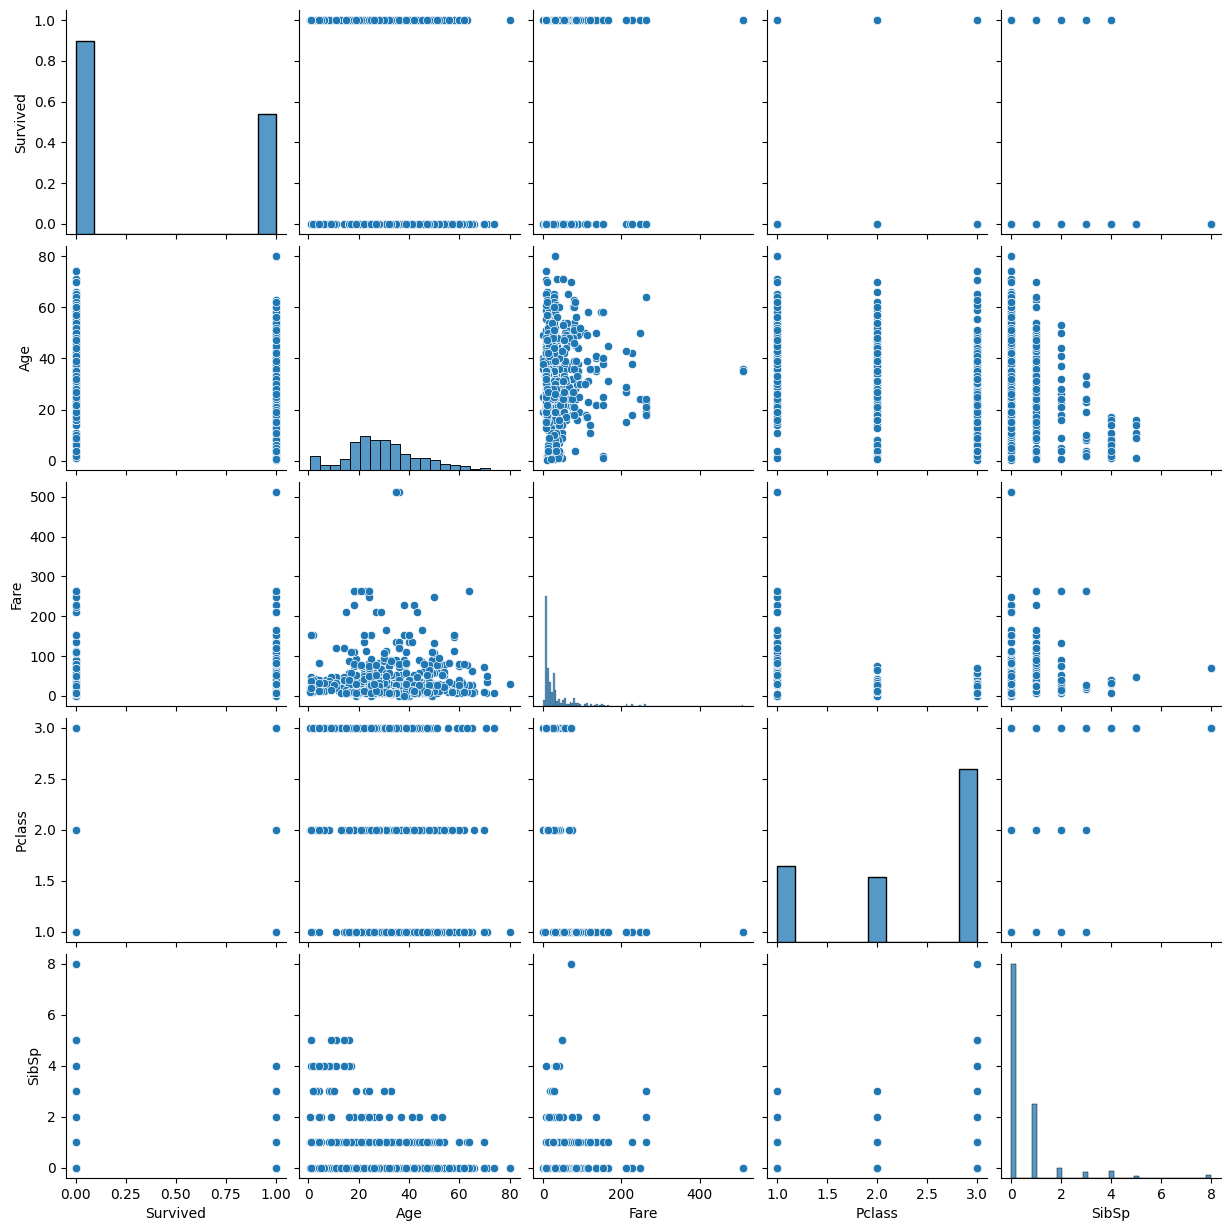

In [48]:
cols = ['Survived', 'Age', 'Fare', 'Pclass', 'SibSp']

sns.pairplot(df[cols])
plt.show()

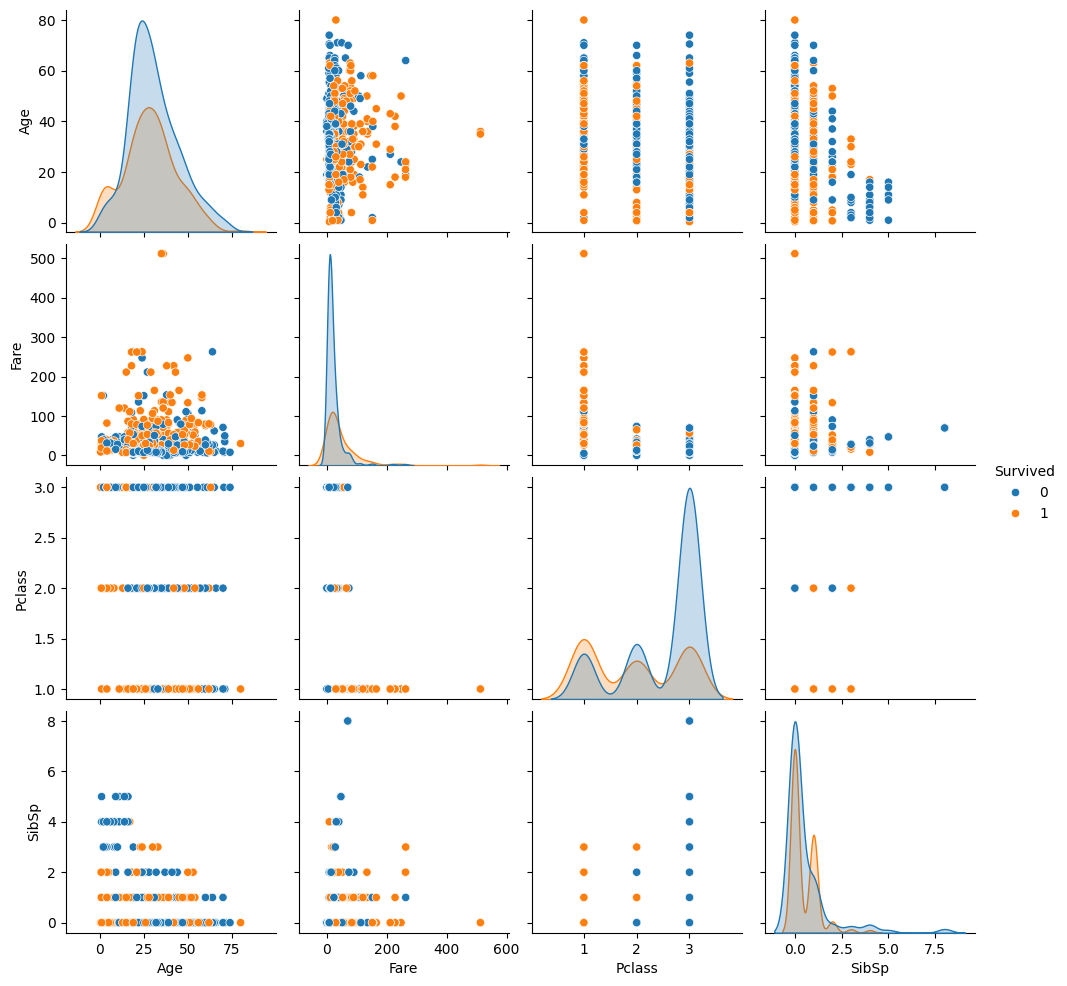

In [49]:
#pair plots for columns with "Survived"
sns.pairplot(
    df[cols],
    hue='Survived'
)

plt.show()

## Identifying Patterns, Trends or Anomalies

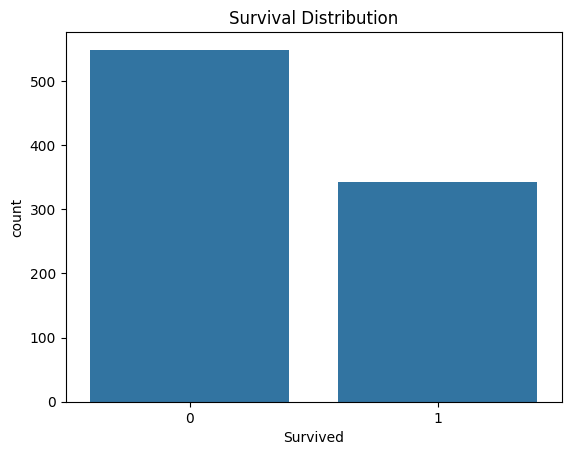

In [50]:
sns.countplot(x='Survived', data=df) # this shows that more people died than survived
plt.title('Survival Distribution')
plt.show()

<Axes: xlabel='Pclass', ylabel='Survived'>

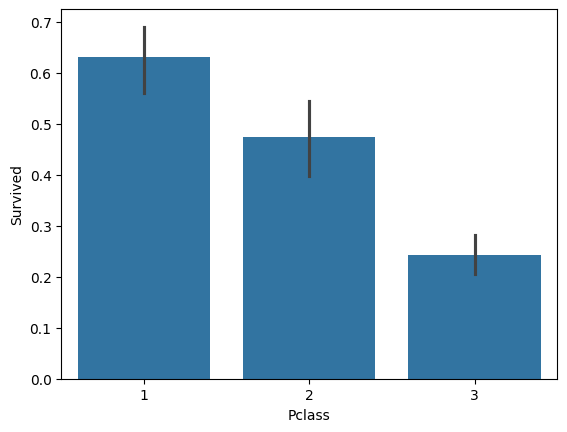

In [51]:
sns.barplot(x='Pclass', y='Survived', data=df) 
#pasengers of better classes has higher survival rates

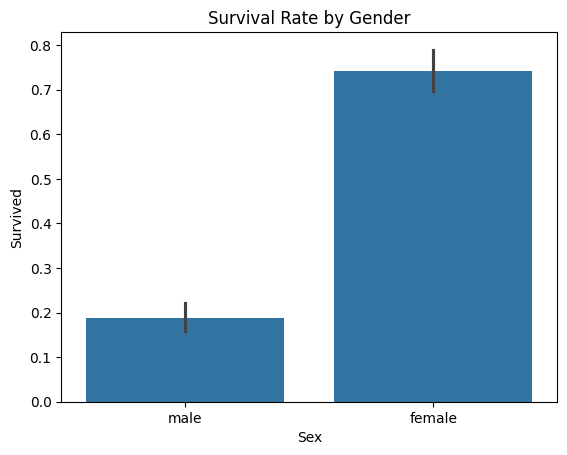

In [52]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()
#female passengers survived at much higher rates than males

<Axes: xlabel='Age', ylabel='Count'>

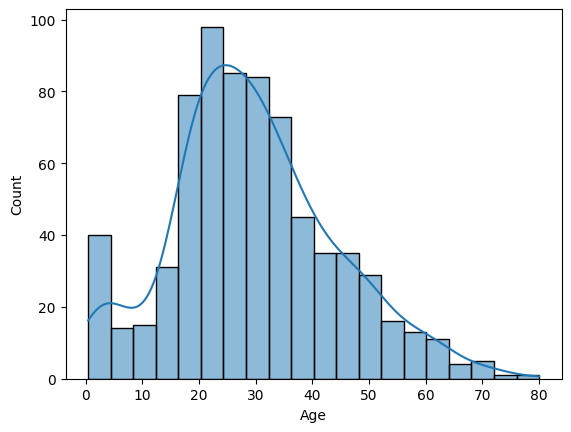

In [53]:
sns.histplot(df['Age'], bins=20, kde=True)
# overall age distribution of all passengers
# most passengers were between 20-40 years old


<Axes: >

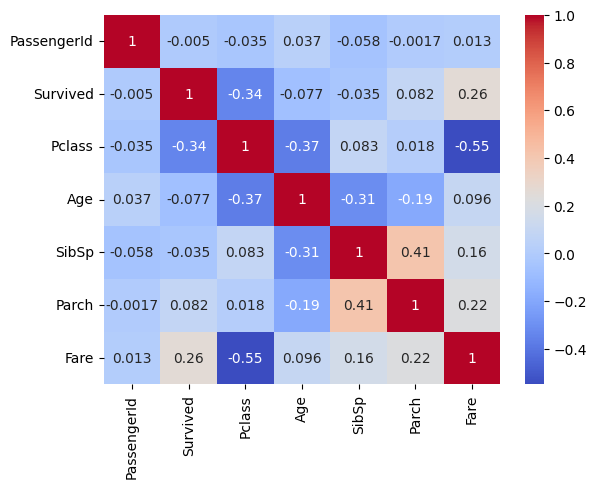

In [54]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
# fare is positively correlated with survival


## Feature-level Inferences from Visuals

- Most passengers were between 20 and 40 years old.
- There were relatively few elderly passengers.
- The age distribution is slightly right-skewed.
- Some age values are missing.

<Axes: xlabel='Fare', ylabel='Count'>

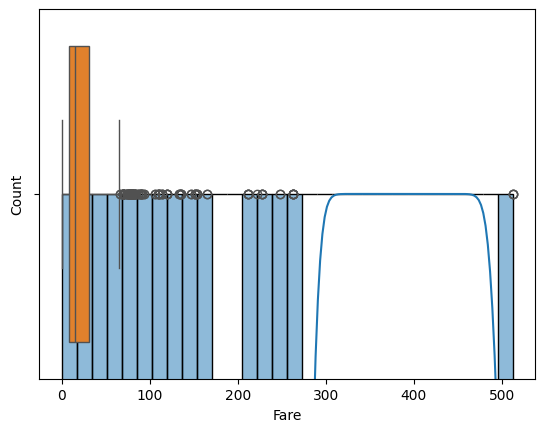

In [55]:
sns.histplot(df['Fare'], bins=30, kde=True)

sns.boxplot(x=df['Fare'])

- Most passengers paid relatively low fares.
- A small number paid very high fares.
- Fare is highly right-skewed.
- Several extreme outliers are present.

<Axes: xlabel='Pclass', ylabel='count'>

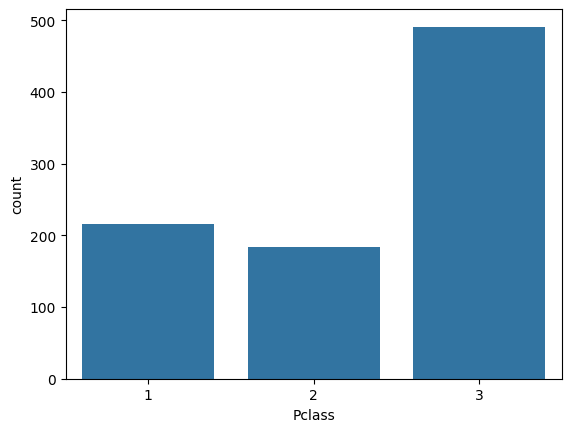

In [56]:
sns.countplot(x='Pclass', data=df)

- Most passengers traveled in third class.
- First-class passengers were fewer in number.
- The dataset contains passengers from all socioeconomic levels.

<Axes: xlabel='Sex', ylabel='Survived'>

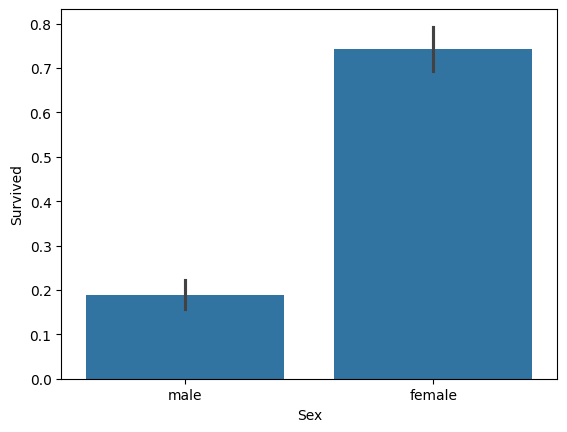

In [57]:
sns.barplot(x='Sex', y='Survived', data=df)

- Female passengers had a much higher survival rate.
- Gender appears to be a strong predictor of survival.

<Axes: xlabel='Pclass', ylabel='Survived'>

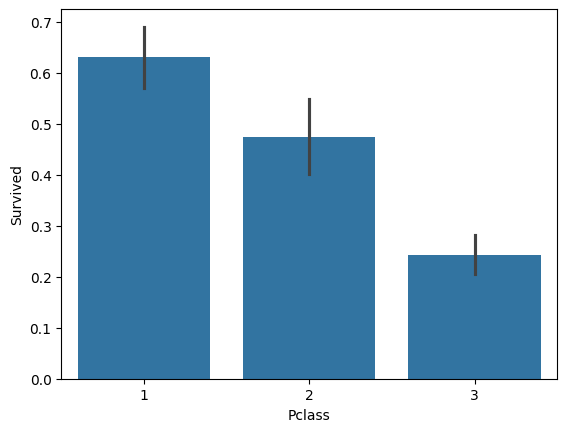

In [58]:
sns.barplot(x='Pclass', y='Survived', data=df)

- First-class passengers were more likely to survive.
- Survival rate decreases from first class to third class.

<Axes: xlabel='SibSp', ylabel='Count'>

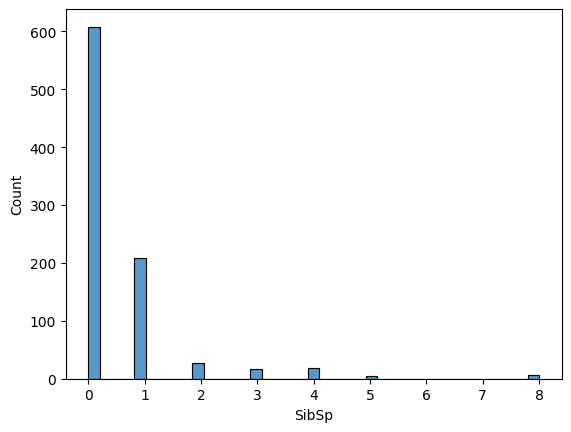

In [59]:
sns.histplot(df['SibSp'])

- Most passengers traveled without siblings or spouses.
- Large family groups were uncommon.

<Axes: xlabel='Parch', ylabel='Count'>

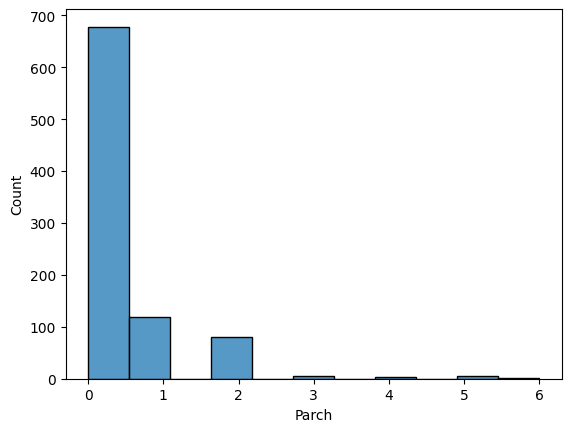

In [60]:
sns.histplot(df['Parch'])

- Most passengers traveled without parents or children.
- Family-related travel was less common.